# QTCAD M06 Charge Stability — Result Analysis

이 노트북은 아래 QTCAD 예제 폴더(`double_dot_stability.py`)의 저장된 결과를
불러와 분석합니다. 대상은 실리콘 FD-SOI(fully-depleted silicon-on-insulator)
이중 양자점(double quantum dot, DQD) 소자입니다.

**Base directory**

`C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M06. Charge stability\Reference`

분석 대상:
- `output/dqdfdsoi_energies.npy` — 단일 전자 궤도 에너지 (4개 상태, J 단위)
- `output/lever_arm_matrix.npy` — 레버암 행렬 (4 states x 2 gates)
- `output/coulomb_mat_no_overlap.npy` — Coulomb 상호작용 행렬 (4x4, J 단위)
- `output/addition_spectrum.txt` — 90x90 particle-addition response (charge
  stability diagram raw data)

참고: 같은 폴더의 `nanowire_diamond.py`는 별도의 단일 양자점(실리콘 나노와이어
트랜지스터) Coulomb-diamond 예제로, 배열을 디스크에 저장하지 않는 plot-only
스크립트입니다. `nanowire_diamond_run.log`를 확인한 결과 solver progress bar
외에 추가로 불러올 수치 결과는 없어 이 노트북에서는 제외합니다.

주요 산출물:
1. 단일 전자 궤도 에너지 스펙트럼 및 준-축퇴 쌍(near-degenerate pair) 확인
2. 레버암 행렬 heatmap 및 게이트-점(dot) 대응관계 도출
3. Coulomb 행렬 heatmap 및 대각/동일-dot/타-dot 항목 비교
4. Addition spectrum을 이용한 charge stability diagram(honeycomb) 재구성
5. Addition spectrum peak 간격과 charging energy/lever arm 기반 추정치 비교

---
## 📚 참고 문서
- **QTCAD 공식 튜토리얼** — Transport 3: Quantum transport—Charge stability diagram of a DQD
  https://docs.nanoacademic.com/qtcad/tutorials/transport/double_dot_stability/
- **QTCAD 공식 튜토리얼** — Transport 1: Quantum transport—Master equation (nanowire_diamond.py, 참고용)
  https://docs.nanoacademic.com/qtcad/tutorials/transport/nanowire_diamond/
- **QTCAD 문서 포털**: https://docs.nanoacademic.com/qtcad/
- 소스 스크립트: `double_dot_stability.py` (M06/Reference)
---


## 0. 소자 스케매틱 + 파라미터 선택 의도

M03/M04/M05/M16과 동일한 FD-SOI 이중양자점 소자입니다 (`dqdfdsoi.geo` 치수 공식).

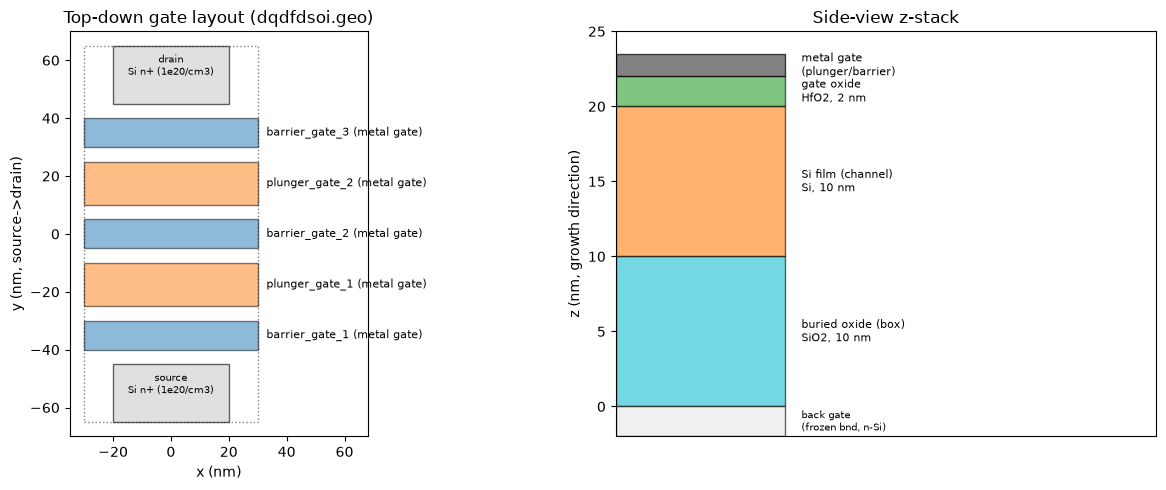

,parameter,intent
0,"V_g1, V_g2 sweep: 30-140 mV (기준 0.6/0.601V 위에 ...",두 plunger 게이트를 각각 110mV 범위로 조밀하게(90점) 스캔 — 여러 ...
1,기준 바이어스 0.6V/0.601V (두 플런저 사이 1mV 비대칭),"완전 대칭(0V 차이)이면 두 dot의 전이선이 완전히 겹쳐 구분이 안 되므로, 아..."


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

BASE_DIR = Path(r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M06. Charge stability\Reference")
OUTPUT_DIR = BASE_DIR / "output"
EXPORT_DIR = OUTPUT_DIR / "analysis_exports_M06"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

domain_width, channel_width = 60.0, 40.0
gaps = [5.0] * 6
barrier_len, plunger_len, sd_len = 10.0, 15.0, 20.0
channel_len = sum(gaps) + 3 * barrier_len + 2 * plunger_len
domain_len = 2 * sd_len + channel_len
temp = -channel_len / 2 + gaps[0]
lens = [barrier_len, plunger_len, barrier_len, plunger_len, barrier_len]
names = ["barrier_gate_1", "plunger_gate_1", "barrier_gate_2", "plunger_gate_2", "barrier_gate_3"]
segs = []
for name, L, gi in zip(names, lens, [1, 2, 3, 4, 5]):
    segs.append((name, temp, temp + L)); temp = temp + gaps[gi] + L

fig, axs = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1.6, 1]})
ax = axs[0]
ax.add_patch(mpatches.Rectangle((-domain_width/2, -domain_len/2), domain_width, domain_len,
                                fill=False, ls=":", ec="0.5"))
ax.add_patch(mpatches.Rectangle((-channel_width/2, -domain_len/2), channel_width, sd_len,
                                fc="0.8", alpha=0.6, ec="k"))
ax.add_patch(mpatches.Rectangle((-channel_width/2, domain_len/2 - sd_len), channel_width, sd_len,
                                fc="0.8", alpha=0.6, ec="k"))
ax.text(0, -domain_len/2 + sd_len/2, "source\nSi n+ (1e20/cm3)", ha="center", fontsize=7)
ax.text(0, domain_len/2 - sd_len/2, "drain\nSi n+ (1e20/cm3)", ha="center", fontsize=7)
for name, y0, y1 in segs:
    ax.add_patch(mpatches.Rectangle((-domain_width/2, y0), domain_width, y1 - y0,
                                    fc="tab:orange" if "plunger" in name else "tab:blue",
                                    alpha=0.5, ec="k"))
    ax.text(domain_width/2 + 3, (y0 + y1) / 2, name + " (metal gate)", va="center", fontsize=8)
ax.set_xlim(-domain_width/2-5, domain_width/2+38); ax.set_ylim(-domain_len/2-5, domain_len/2+5)
ax.set_aspect("equal"); ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm, source->drain)")
ax.set_title("Top-down gate layout (dqdfdsoi.geo)")

ax2 = axs[1]
z_layers = [("buried oxide (box)\nSiO2, 10 nm", 10, "tab:cyan"),
           ("Si film (channel)\nSi, 10 nm", 10, "tab:orange"),
           ("gate oxide\nHfO2, 2 nm", 2, "tab:green")]
z0 = 0
for name, thick, color in z_layers:
    ax2.add_patch(mpatches.Rectangle((0, z0), 1, thick, fc=color, alpha=0.6, ec="k"))
    ax2.text(1.1, z0 + thick/2, name, va="center", fontsize=8)
    z0 += thick
ax2.add_patch(mpatches.Rectangle((0, z0), 1, 1.5, fc="0.3", alpha=0.7, ec="k"))
ax2.text(1.1, z0 + 0.75, "metal gate\n(plunger/barrier)", va="center", fontsize=8)
ax2.set_xlim(0, 3.2); ax2.set_ylim(-2, z0 + 3)
ax2.add_patch(mpatches.Rectangle((0, -2), 1, 2, fc="0.9", alpha=0.6, ec="k"))
ax2.text(1.1, -1, "back gate\n(frozen bnd, n-Si)", va="center", fontsize=7)
ax2.set_xticks([]); ax2.set_ylabel("z (nm, growth direction)")
ax2.set_title("Side-view z-stack")
fig.tight_layout()

fig.savefig(EXPORT_DIR / "device_schematic_top_view.png", dpi=150)
plt.show()

param_intent = pd.DataFrame([
    {"parameter": "V_g1, V_g2 sweep: 30-140 mV (기준 0.6/0.601V 위에 추가), 90x90",
     "intent": "두 plunger 게이트를 각각 110mV 범위로 조밀하게(90점) 스캔 — 여러 개의 "
               "전하 전이선(honeycomb 격자 여러 칸)을 한 지도에 담을 만큼 넓으면서, "
               "선 모양이 흐려지지 않을 만큼 조밀한 해상도."},
    {"parameter": "기준 바이어스 0.6V/0.601V (두 플런저 사이 1mV 비대칭)",
     "intent": "완전 대칭(0V 차이)이면 두 dot의 전이선이 완전히 겹쳐 구분이 안 되므로, "
               "아주 작은 비대칭을 줘 두 dot을 시각적으로 구별 가능하게 만드는 전형적 기법."},
])
display(param_intent)
param_intent.to_csv(EXPORT_DIR / "parameter_intent.csv", index=False)


In [2]:
# [동작] 기본 패키지 및 경로 설정
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from qtcad.device import constants as ct

BASE_DIR = Path(
    r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M06. Charge stability\Reference"
)
OUTPUT_DIR = BASE_DIR / "output"

FILE_ENERGIES = OUTPUT_DIR / "dqdfdsoi_energies.npy"
FILE_LEVER_ARM = OUTPUT_DIR / "lever_arm_matrix.npy"
FILE_COULOMB = OUTPUT_DIR / "coulomb_mat_no_overlap.npy"
FILE_ADD_SPECTRUM = OUTPUT_DIR / "addition_spectrum.txt"

EXPORT_DIR = OUTPUT_DIR
SAVE_FIGURES = True

print("BASE_DIR  :", BASE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

assert BASE_DIR.exists(), f"Base directory가 없습니다:\n{BASE_DIR}"
assert OUTPUT_DIR.exists(), f"output 폴더가 없습니다:\n{OUTPUT_DIR}"

print("\n[OK] 기본 경로 확인 완료")


|  ||  |||                                                                 \\  
|  ||  |||         @@@@     @@@@@@@@      @@@@@        @       @@@@@@@      \\ 
|  ||  |||      @@@   @@@      @@      @@@    @       @@       @@    @@@     \\
|  ||  |||     @@       @@     @@     @@             @ @@      @@     @@@     \\
|  ||  |||     @@       @@     @@     @@            @    @     @@      @@     //
|  ||  |||      @@     @@      @@      @@@    @    @@@@@@@@    @@    @@@     //
|  ||  |||        @@@@@@       @@        @@@@@@   @@      @@   @@@@@@       // 
|  ||  |||             @@                                                  //   

                                 Version 2.2.6                                  
  Copyright (c) 2022-2026 Nanoacademic Technologies Inc. All rights reserved.   

      Welcome to QTCAD, the Quantum-Technology Computer-Aided Design tool.      

                        For documentation, please visit:                        
                      https:/

BASE_DIR  : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M06. Charge stability\Reference
OUTPUT_DIR: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M06. Charge stability\Reference\output

[OK] 기본 경로 확인 완료


In [3]:
# [점검] 파일 inventory
expected_files = {
    "dqdfdsoi_energies.npy": FILE_ENERGIES,
    "lever_arm_matrix.npy": FILE_LEVER_ARM,
    "coulomb_mat_no_overlap.npy": FILE_COULOMB,
    "addition_spectrum.txt": FILE_ADD_SPECTRUM,
}

rows = []
for label, path in expected_files.items():
    rows.append({
        "file": label,
        "exists": path.exists(),
        "size_KB": path.stat().st_size / 1024 if path.exists() else np.nan,
        "path": str(path),
    })

inventory_df = pd.DataFrame(rows)
display(inventory_df)

missing = inventory_df.loc[~inventory_df["exists"], "file"].tolist()
if missing:
    print("\n[주의] 없는 파일:", missing)
else:
    print("\n[OK] 분석 대상 파일이 모두 존재합니다.")

,file,exists,size_KB,path
0,dqdfdsoi_energies.npy,True,0.156250,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
1,lever_arm_matrix.npy,True,0.187500,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
2,coulomb_mat_no_overlap.npy,True,0.250000,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...
3,addition_spectrum.txt,True,197.841797,C:\Users\norma\Desktop\연구자료\QTCAD Simulation\S...



[OK] 분석 대상 파일이 모두 존재합니다.


## 1. 단일 전자 궤도 에너지 (orbital energies)

`dqdfdsoi_energies.npy`는 Schrodinger solver가 계산한 4개 궤도의 에너지를
J 단위로 저장한 배열입니다 (`subdvc.energies`). 두 양자점은 거의 대칭으로
바이어스되어 있으므로(plunger gate 2가 plunger gate 1보다 1 mV만 높음),
4개 상태는 두 개의 준-축퇴(near-degenerate) 쌍으로 나뉠 것으로 예상됩니다.

In [4]:
# [동작] 궤도 에너지 로드 및 단위 변환 (J -> meV)
energies_J = np.load(FILE_ENERGIES)
energies_meV = energies_J / ct.e * 1e3

energies_df = pd.DataFrame({
    "state": np.arange(len(energies_meV)),
    "energy_J": energies_J,
    "energy_meV": energies_meV,
})
display(energies_df)

gaps_meV = np.diff(energies_meV)
gaps_df = pd.DataFrame({
    "gap": [f"E{i+1}-E{i}" for i in range(len(gaps_meV))],
    "gap_meV": gaps_meV,
})
display(gaps_df)

,state,energy_J,energy_meV
0,0,6.581030e-21,41.075558
1,1,6.701557e-21,41.827830
2,2,7.375528e-21,46.034426
3,3,7.494479e-21,46.776860


,gap,gap_meV
0,E1-E0,0.752272
1,E2-E1,4.206596
2,E3-E2,0.742435


In [5]:
# [점검] 준-축퇴 쌍(near-degenerate pair) 패턴 확인
degenerate_pairs = [(i, i + 1) for i in range(len(gaps_meV)) if gaps_meV[i] < 2.0]
print("Gap < 2 meV 기준으로 찾은 준-축퇴 쌍:", degenerate_pairs)
print(
    "\n[해석] 상태 {0,1}은 두 점(dot)의 '바닥상태(ground orbital)'가 서로 거의 "
    "축퇴된 쌍이고, 상태 {2,3}은 두 점의 '첫 들뜬상태(first-excited orbital)'가 "
    "서로 거의 축퇴된 쌍입니다 (같은 점 내부의 서로 다른 궤도 쌍이 아님에 유의). "
    "이는 두 점이 거의 대칭적으로 설계·바이어스되었기 때문입니다."
)

Gap < 2 meV 기준으로 찾은 준-축퇴 쌍: [(0, 1), (2, 3)]

[해석] 상태 {0,1}은 두 점(dot)의 '바닥상태(ground orbital)'가 서로 거의 축퇴된 쌍이고, 상태 {2,3}은 두 점의 '첫 들뜬상태(first-excited orbital)'가 서로 거의 축퇴된 쌍입니다 (같은 점 내부의 서로 다른 궤도 쌍이 아님에 유의). 이는 두 점이 거의 대칭적으로 설계·바이어스되었기 때문입니다.


## 2. 레버암 행렬 (lever-arm matrix)

레버암 행렬 원소 $\alpha_{ij} = \partial E_i/\partial (eV_j)$는 게이트 $j$의
전압을 미소 변화시켰을 때 궤도 $i$의 에너지가 얼마나 이동하는지를 나타냅니다.
이는 게이트 전압 축을 에너지 축으로 환산하는 표준 도구이며, 그 구조로부터
**어떤 궤도가 어떤 점(dot)에 국소화되어 있는지** 알 수 있습니다: 특정 게이트
아래에 국소화된 궤도는 그 게이트에 대해 레버암이 1에 가깝고, 반대편(먼) 게이트에
대해서는 0에 가깝습니다.

In [6]:
# [동작] 레버암 행렬 로드 (shape: 4 states x 2 gates, 무차원)
lever_arm = np.load(FILE_LEVER_ARM)
gate_names = ["plunger_gate_1", "plunger_gate_2"]

lever_arm_df = pd.DataFrame(
    lever_arm, columns=gate_names, index=[f"state {i}" for i in range(lever_arm.shape[0])]
)
display(lever_arm_df)

,plunger_gate_1,plunger_gate_2
state 0,0.006224,0.764854
state 1,0.764999,0.006693
state 2,0.006232,0.764499
state 3,0.764571,0.006589


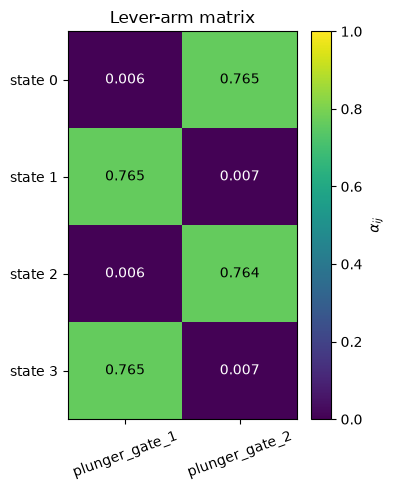

In [7]:
# [실험] 레버암 행렬 heatmap
fig, ax = plt.subplots(figsize=(4, 5))
im = ax.imshow(lever_arm, cmap="viridis", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(gate_names)))
ax.set_xticklabels(gate_names, rotation=20)
ax.set_yticks(range(lever_arm.shape[0]))
ax.set_yticklabels([f"state {i}" for i in range(lever_arm.shape[0])])
ax.set_title("Lever-arm matrix")
for i in range(lever_arm.shape[0]):
    for j in range(lever_arm.shape[1]):
        ax.text(j, i, f"{lever_arm[i, j]:.3f}", ha="center", va="center",
                 color="white" if lever_arm[i, j] < 0.5 else "black")
fig.colorbar(im, ax=ax, label=r"$\alpha_{ij}$")
fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(EXPORT_DIR / "analysis_lever_arm_heatmap.png", dpi=150)
plt.show()

In [8]:
# [점검] 상태 -> 지배적 게이트(=점) 대응관계 도출
dominant_gate = np.argmax(lever_arm, axis=1)
assign_rows = []
for i, g in enumerate(dominant_gate):
    assign_rows.append({
        "state": i,
        "dominant_gate": gate_names[g],
        "alpha_dominant": lever_arm[i, g],
        "alpha_other": lever_arm[i, 1 - g],
    })
assign_df = pd.DataFrame(assign_rows)
display(assign_df)

print(
    "\n[해석] 상태 0, 2는 plunger_gate_2 아래의 점에, 상태 1, 3은 "
    "plunger_gate_1 아래의 점에 국소화되어 있습니다. 즉 각 점은 앞서 찾은 두 "
    "준-축퇴 쌍({0,1}과 {2,3}) 중 하나씩의 구성원을 가지고 있습니다 "
    "(dot 1 = {state 1, state 3}, dot 2 = {state 0, state 2}). "
    "레버암이 정확히 1이 아니라 ~0.76인 이유는 게이트 전압 변화의 일부가 "
    "이웃 점으로 새어 들어가고, 주변 산화막/기판/다른 게이트에 의해 결합이 "
    "다소 screening되기 때문입니다."
)

,state,dominant_gate,alpha_dominant,alpha_other
0,0,plunger_gate_2,0.764854,0.006224
1,1,plunger_gate_1,0.764999,0.006693
2,2,plunger_gate_2,0.764499,0.006232
3,3,plunger_gate_1,0.764571,0.006589



[해석] 상태 0, 2는 plunger_gate_2 아래의 점에, 상태 1, 3은 plunger_gate_1 아래의 점에 국소화되어 있습니다. 즉 각 점은 앞서 찾은 두 준-축퇴 쌍({0,1}과 {2,3}) 중 하나씩의 구성원을 가지고 있습니다 (dot 1 = {state 1, state 3}, dot 2 = {state 0, state 2}). 레버암이 정확히 1이 아니라 ~0.76인 이유는 게이트 전압 변화의 일부가 이웃 점으로 새어 들어가고, 주변 산화막/기판/다른 게이트에 의해 결합이 다소 screening되기 때문입니다.


## 3. Coulomb 상호작용 행렬 (Coulomb matrix)

`coulomb_mat_no_overlap.npy`는 4개 궤도 사이의 직접(overlap 항 제외) Coulomb
행렬원소 $U_{ij} = \langle ij|V_{ee}|ij\rangle$를 J 단위로 담고 있습니다.
**대각 원소**는 같은 궤도에 전자를 하나 더 채울 때의 self-charging 에너지이고,
**비대각 원소**는 두 궤도가 같은 점에 속하는지(intra-dot) 다른 점에 속하는지
(inter-dot)에 따라 물리적 의미가 달라집니다: 동일 점 내부의 서로 다른 궤도 간
반발은 상대적으로 크고, 서로 다른 점 사이의 상호 Coulomb 결합은 공간적으로
떨어져 있어 상대적으로 작습니다. 이 inter-dot 결합이 바로 이중 양자점의
honeycomb charge-stability diagram을 만드는 핵심 요소입니다.

In [9]:
# [동작] Coulomb 행렬 로드 및 단위 변환 (J -> meV)
coulomb_J = np.load(FILE_COULOMB)
coulomb_meV = coulomb_J / ct.e * 1e3

coulomb_df = pd.DataFrame(
    coulomb_meV,
    columns=[f"orbital {j}" for j in range(4)],
    index=[f"orbital {i}" for i in range(4)],
)
display(coulomb_df.round(3))

,orbital 0,orbital 1,orbital 2,orbital 3
orbital 0,18.611,3.292,14.749,3.217
orbital 1,3.292,18.528,3.220,14.705
orbital 2,14.749,3.220,15.560,3.151
orbital 3,3.217,14.705,3.151,15.518


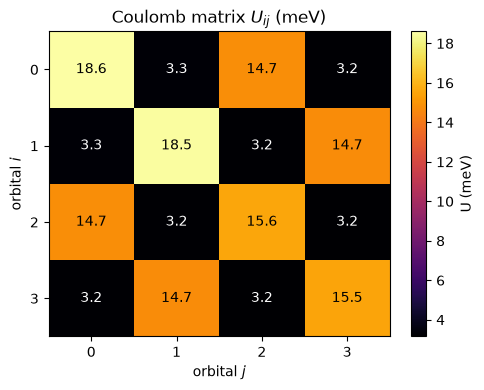

In [10]:
# [실험] Coulomb 행렬 heatmap
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(coulomb_meV, cmap="inferno", aspect="auto")
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xlabel("orbital $j$")
ax.set_ylabel("orbital $i$")
ax.set_title("Coulomb matrix $U_{ij}$ (meV)")
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{coulomb_meV[i, j]:.1f}", ha="center", va="center",
                 color="white" if coulomb_meV[i, j] < coulomb_meV.max()/2 else "black")
fig.colorbar(im, ax=ax, label="U (meV)")
fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(EXPORT_DIR / "analysis_coulomb_heatmap.png", dpi=150)
plt.show()

In [11]:
# [점검] 대각 / same-dot / inter-dot 항목 분류 및 비교
same_dot_pairs = [(0, 2), (1, 3)]     # 같은 점(dot 2, dot 1)의 서로 다른 궤도
diff_dot_pairs = [(0, 1), (0, 3), (2, 1), (2, 3)]  # 서로 다른 점의 궤도

same_dot_vals = [coulomb_meV[i, j] for i, j in same_dot_pairs]
diff_dot_vals = [coulomb_meV[i, j] for i, j in diff_dot_pairs]

category_df = pd.DataFrame({
    "category": ["diagonal (self-charging)", "same-dot off-diagonal", "inter-dot off-diagonal"],
    "mean_meV": [np.mean(np.diag(coulomb_meV)), np.mean(same_dot_vals), np.mean(diff_dot_vals)],
    "min_meV": [np.min(np.diag(coulomb_meV)), np.min(same_dot_vals), np.min(diff_dot_vals)],
    "max_meV": [np.max(np.diag(coulomb_meV)), np.max(same_dot_vals), np.max(diff_dot_vals)],
})
display(category_df.round(3))

print(
    "\n[해석] Diagonal(self-charging) > same-dot(intra-dot) > inter-dot 순서의 "
    "계층 구조가 뚜렷합니다 (~18-19 meV > ~14-15 meV > ~3 meV). 이는 같은 궤도가 "
    "가장 좁은 영역에 겹쳐 있고, 같은 점의 서로 다른 궤도는 공간적으로 많이 "
    "겹치며, 서로 다른 점은 상대적으로 멀리 떨어져 있어 Coulomb 꼬리(tail)로만 "
    "결합하기 때문입니다. 아래 charge stability diagram에서, intra-dot 항목은 "
    "honeycomb 셀의 전체 크기를, inter-dot 항목은 경계선의 기울기를 결정합니다."
)

,category,mean_meV,min_meV,max_meV
0,diagonal (self-charging),17.054,15.518,18.611
1,same-dot off-diagonal,14.727,14.705,14.749
2,inter-dot off-diagonal,3.220,3.151,3.292



[해석] Diagonal(self-charging) > same-dot(intra-dot) > inter-dot 순서의 계층 구조가 뚜렷합니다 (~18-19 meV > ~14-15 meV > ~3 meV). 이는 같은 궤도가 가장 좁은 영역에 겹쳐 있고, 같은 점의 서로 다른 궤도는 공간적으로 많이 겹치며, 서로 다른 점은 상대적으로 멀리 떨어져 있어 Coulomb 꼬리(tail)로만 결합하기 때문입니다. 아래 charge stability diagram에서, intra-dot 항목은 honeycomb 셀의 전체 크기를, inter-dot 항목은 경계선의 기울기를 결정합니다.


## 4. Charge stability diagram (addition spectrum)

`addition_spectrum.txt`는 두 plunger 게이트 전압 $V_{g1}, V_{g2} \in [30, 140]$
mV(기준 바이어스 0.6 V, 0.601 V 위에 추가)를 스윕하며 계산한 90x90 크기의
many-body particle-addition response 격자입니다. 이 response 함수의 날카로운
ridge는 DQD의 전자 개수가 1개씩 바뀌는 전하 전이(charge transition) 선이며,
이 선들이 모여 전형적인 honeycomb 패턴을 만듭니다.

**물리 모델 — Addition Spectrum (M05 1절과 동일한 요동-소산 정리)**:
$$
\frac{\partial \langle N \rangle}{\partial \mu} = \frac{\langle N^2\rangle - \langle N\rangle^2}{k_B T}
$$
이 양을 $(V_{g1}, V_{g2})$ 평면 전체에서 계산하면, 전자 수가 바뀌는 경계(날카로운
ridge)가 바로 전하 안정성 지도의 전이선이 됩니다. 이중양자점에서는 각 dot이 독립적으로
전자를 얻거나 잃을 수 있어, 두 방향의 전이선이 교차하며 특징적인 **honeycomb(육각
벌집) 패턴**을 만듭니다 — 이것이 실험 CSD(charge stability diagram)와 직접 비교되는
표준 신호입니다.

In [12]:
# [동작] addition_spectrum.txt 로드 (90x90 grid, arbitrary units) 및 전압 축 재구성
add_spec = np.loadtxt(FILE_ADD_SPECTRUM)
print("addition_spectrum shape:", add_spec.shape)

min_gate_1_bias, max_gate_1_bias = 30e-3, 140e-3
min_gate_2_bias, max_gate_2_bias = 30e-3, 140e-3
vg1_ref, vg2_ref = 0.6, 0.6 + 1e-3
gate_1_biases = np.linspace(min_gate_1_bias, max_gate_1_bias, 90) + vg1_ref
gate_2_biases = np.linspace(min_gate_2_bias, max_gate_2_bias, 90) + vg2_ref

addition_spectrum shape: (90, 90)


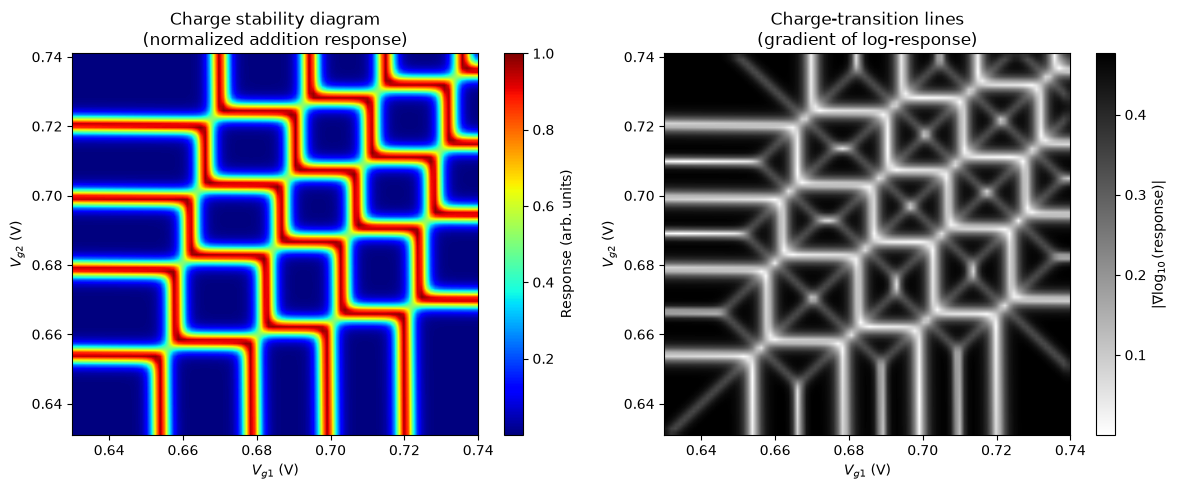

In [13]:
# [실험] Charge stability diagram (원본 response) + gradient 기반 전이선 강조
# 원본 스크립트와 동일한 관례: transpose + flip으로 Vg1을 x축, Vg2를 y축(위로
# 증가)에 배치.
add_spec_img = np.flip(np.transpose(add_spec), axis=0)
add_spec_norm = add_spec_img / np.max(add_spec_img)
extent = [gate_1_biases[0], gate_1_biases[-1], gate_2_biases[0], gate_2_biases[-1]]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

im0 = axs[0].imshow(add_spec_norm, cmap="jet", interpolation="bilinear",
                     extent=extent, aspect="auto")
axs[0].set_xlabel("$V_{g1}$ (V)")
axs[0].set_ylabel("$V_{g2}$ (V)")
axs[0].set_title("Charge stability diagram\n(normalized addition response)")
fig.colorbar(im0, ax=axs[0], label="Response (arb. units)")

# Charge-transition line은 response가 가장 빠르게 변하는 곳이므로, 로그 압축한
# response의 gradient magnitude로 honeycomb 경계선을 강조합니다.
log_resp = np.log10(add_spec_img)
gy, gx = np.gradient(log_resp)
grad_mag = np.sqrt(gx**2 + gy**2)

im1 = axs[1].imshow(grad_mag, cmap="gray_r", interpolation="bilinear",
                     extent=extent, aspect="auto")
axs[1].set_xlabel("$V_{g1}$ (V)")
axs[1].set_ylabel("$V_{g2}$ (V)")
axs[1].set_title("Charge-transition lines\n(gradient of log-response)")
fig.colorbar(im1, ax=axs[1], label=r"$|\nabla \log_{10}(\mathrm{response})|$")

fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(EXPORT_DIR / "analysis_charge_stability_diagram.png", dpi=150)
plt.show()

In [14]:
# [점검] Peak 간격 추정 및 charging-energy/lever-arm 기반 추정치와 비교
mid_row = add_spec_img.shape[0] // 2
line_cut_vs_vg1 = add_spec_img[mid_row, :]
peak_idx = np.sort(np.argsort(line_cut_vs_vg1)[-6:])  # response가 가장 큰 6개 지점
peak_voltages = gate_1_biases[peak_idx]

print("Vg2 고정(mid-scan)에서 response가 가장 큰 Vg1 위치들 (V):",
      np.round(peak_voltages, 4))

if len(peak_voltages) > 1:
    spacings = np.diff(peak_voltages)
    est_spacing_V = coulomb_meV[1, 1] / (lever_arm[1, 0] * 1e3)
    print(f"관측된 평균 간격: {np.mean(spacings)*1e3:.1f} mV")
    print(
        f"Charging energy / lever arm으로 추정한 크기 척도 (state 1, dot 1 "
        f"기준): {est_spacing_V:.3f} V (order-of-magnitude 비교용)"
    )

Vg2 고정(mid-scan)에서 response가 가장 큰 Vg1 위치들 (V): [0.6609 0.6621 0.7017 0.7029 0.7239 0.7252]
관측된 평균 간격: 12.9 mV
Charging energy / lever arm으로 추정한 크기 척도 (state 1, dot 1 기준): 0.024 V (order-of-magnitude 비교용)


## 5. 최종 요약

In [15]:
# [점검] 핵심 결과 요약
print("=" * 88)
print("QTCAD M06 CHARGE STABILITY — ANALYSIS SUMMARY")
print("=" * 88)
print(f"Orbital energies (meV)          : {np.round(energies_meV, 4)}")
print(f"Near-degenerate pairs           : {degenerate_pairs}")
print(f"Lever arm (dominant, mean)      : {np.mean(np.max(lever_arm, axis=1)):.4f}")
print(f"Lever arm (cross, mean)         : {np.mean(np.min(lever_arm, axis=1)):.5f}")
print(f"Coulomb diagonal mean (meV)     : {np.mean(np.diag(coulomb_meV)):.3f}")
print(f"Coulomb same-dot mean (meV)     : {np.mean(same_dot_vals):.3f}")
print(f"Coulomb inter-dot mean (meV)    : {np.mean(diff_dot_vals):.3f}")
print(f"addition_spectrum grid shape    : {add_spec.shape}")
print(f"Analysis export directory       : {EXPORT_DIR}")
print("=" * 88)

QTCAD M06 CHARGE STABILITY — ANALYSIS SUMMARY
Orbital energies (meV)          : [41.0756 41.8278 46.0344 46.7769]
Near-degenerate pairs           : [(0, 1), (2, 3)]
Lever arm (dominant, mean)      : 0.7647
Lever arm (cross, mean)         : 0.00643
Coulomb diagonal mean (meV)     : 17.054
Coulomb same-dot mean (meV)     : 14.727
Coulomb inter-dot mean (meV)    : 3.220
addition_spectrum grid shape    : (90, 90)
Analysis export directory       : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M06. Charge stability\Reference\output


## 해석 주의사항

- `dqdfdsoi_energies.npy`, `coulomb_mat_no_overlap.npy`는 J(SI) 단위로
  저장되어 있으므로, eV/meV로 볼 때는 `ct.e`로 나누어야 합니다.
- `lever_arm_matrix.npy`의 행(row)은 궤도(orbital) 인덱스, 열(column)은
  게이트 인덱스(`plunger_gate_1`, `plunger_gate_2`)입니다. 이 노트북에서
  확인한 것처럼 상태 0,2는 plunger_gate_2 쪽 점, 상태 1,3은 plunger_gate_1
  쪽 점에 속하므로, "상태 인덱스 순서 = 점 인덱스 순서"라고 가정하면 안 됩니다.
- `coulomb_mat_no_overlap.npy`는 overlap 항을 제외한 직접(Coulomb) 항만
  포함하며, exchange/overlap 항은 포함하지 않습니다 (원본 스크립트에서
  `overlap=False`로 계산).
- `addition_spectrum.txt`는 접합 온도를 10 K로 높여 계산한 결과입니다
  (원 스크립트 주석: 실제 동작 온도인 100 mK보다 선을 두껍게 만들어 격자
  해상도 요구량을 낮추기 위함). 따라서 이 diagram의 선폭을 실제 소자의
  linewidth로 해석해서는 안 됩니다.
- `addition_spectrum` 값의 절대 스케일(arb. units)은 물리적으로 보정되지
  않았으므로, 이 노트북에서는 최댓값으로 정규화한 상대적인 response만
  사용합니다.
print("\nDone.")